# Bootstrap & permutation on different data: wetsuits

*Part 2 · Lesson 20 · another dataset  ·  data: Swim velocities (paired, n=12)*

*↩ A companion to [Lesson 20: The bootstrap & permutation tests](20-bootstrap-permutation.ipynb).*

**↩ Back:** [Lesson 20: The bootstrap & permutation tests](20-bootstrap-permutation.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  **Also:** [The code behind it →](20-bootstrap-permutation~the-code.ipynb)

The core lesson used resampling on roomy datasets — **272** Old Faithful eruptions and **60** guinea
pigs. That is comfortable territory. This companion does the opposite: it hands you a sample so small
you could write every value on the back of your hand. **Twelve** competitive swimmers each swam a fixed
course **twice**, once in a wetsuit and once in an ordinary swimsuit, and we recorded the speed each
time. The question: **does a wetsuit actually make you faster?**

Twelve numbers is exactly where the textbook formulas get nervous — there is barely enough data to
check whether anything is "roughly normal." It is also exactly where **resampling earns its keep.** We
will reuse the two moves from the core lesson — the **bootstrap** (resample WITH replacement to get a
confidence interval) and the **permutation test** (shuffle to build a null distribution and read off a
p-value) — and watch them give honest answers from a tiny sample, with no normality assumption. Run
each grey cell with **Shift+Enter**, then tinker.

> **New to notebooks?** The grey boxes below are **code**. Click one and press **Shift + Enter** to run it — the result (a number, a table, or a chart) appears right underneath. Run them **top to bottom**. You do **not** need to understand the first *"Setup"* cell — it just loads the tools and the data, so run it and move on. And you **can't break anything**: re-running a cell is always safe. *(Brand new to all this? The five-minute [Lesson 0 — How these notebooks work](00-how-these-notebooks-work.ipynb) shows you the basics first.)*

In [1]:
# --- Setup: load our helpers and the data --------------------------------
import sys, pathlib
for _p in [pathlib.Path.cwd(), pathlib.Path.cwd().parent]:
    if (_p / 'lib' / 'statslab.py').exists():
        sys.path.insert(0, str(_p / 'lib')); break
import statslab as sl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
sl.use_course_style()

SEED = 20                                   # fixed seed -> everyone gets the same resampling "world"

SWIM_URL = 'https://www.openintro.org/data/csv/swim.csv'
sw = sl.load_csv('swim.csv', url=SWIM_URL)

# The dotted column names are accessed with bracket lookup, not sw.wet...
wet  = sw['wet.suit.velocity'].to_numpy()    # speed in a WETSUIT  (m/s)
swim = sw['swim.suit.velocity'].to_numpy()   # speed in a SWIMSUIT (m/s)
print(f'{len(sw)} swimmers, each timed twice (wetsuit and swimsuit). Velocities in m/s.')
sw

12 swimmers, each timed twice (wetsuit and swimsuit). Velocities in m/s.


,swimmer.number,wet.suit.velocity,swim.suit.velocity,velocity.diff
0,1,1.57,1.49,0.08
1,2,1.47,1.37,0.10
2,3,1.42,1.35,0.07
3,4,1.35,1.27,0.08
4,5,1.22,1.12,0.10
5,6,1.75,1.64,0.11
6,7,1.64,1.59,0.05
7,8,1.57,1.52,0.05
8,9,1.56,1.50,0.06
9,10,1.53,1.45,0.08


## 1) A *paired* design — each swimmer is their own control

Before any resampling, notice the shape of this experiment. We did **not** put 12 swimmers in wetsuits
and a *different* 12 in swimsuits. The **same** swimmer swam both ways. That is a **paired design**: the
two measurements come in matched couples, one per swimmer.

Pairing is a gift, because swimmers differ enormously — an Olympic sprinter is faster than a club
swimmer in *anything* they wear. If we compared "all wetsuit swims" against "all swimsuit swims" as two
separate piles, that swimmer-to-swimmer variation would swamp the small wetsuit effect we are hunting
for. Instead we look at each swimmer's **own difference**:

$$d_i \;=\; (\text{wetsuit velocity})_i \;-\; (\text{swimsuit velocity})_i.$$

A positive $d_i$ means swimmer $i$ was faster in the wetsuit. By subtracting *within* each swimmer, the
"how fast is this person" part cancels out, and we are left with **one number per swimmer** that
isolates the wetsuit effect. From here on, our entire dataset is just these **12 differences**.

In [2]:
d = wet - swim                              # one paired difference per swimmer (m/s)
n = len(d)

# Sanity check: the file already ships a precomputed 'velocity.diff' column.
print('our d              :', np.round(d, 3))
print("file 'velocity.diff':", np.round(sw['velocity.diff'].to_numpy(), 3))
print('the two agree exactly:', np.allclose(d, sw['velocity.diff'].to_numpy()))

print(f'\nn = {n} paired differences (m/s)')
print(f'faster in the wetsuit for {(d > 0).sum()} of {n} swimmers')
print(f'observed MEAN boost = {d.mean():.4f} m/s   (= {d.mean()*100:.1f} cm/s)')
print(f'sample SD of the 12 differences = {d.std(ddof=1):.4f} m/s')

our d              : [0.08 0.1  0.07 0.08 0.1  0.11 0.05 0.05 0.06 0.08 0.05 0.1 ]
file 'velocity.diff': [0.08 0.1  0.07 0.08 0.1  0.11 0.05 0.05 0.06 0.08 0.05 0.1 ]
the two agree exactly: True

n = 12 paired differences (m/s)
faster in the wetsuit for 12 of 12 swimmers
observed MEAN boost = 0.0775 m/s   (= 7.8 cm/s)
sample SD of the 12 differences = 0.0218 m/s


Every single one of the 12 swimmers was faster in the wetsuit, by small amounts on the order of
**0.05–0.11 m/s**. The average boost is about **0.08 m/s**. That looks convincing — but with only
**12** numbers, the honest question is whether a gap this size could be a fluke of *which* twelve people
we happened to test. Let's picture the 12 differences before we quantify anything.

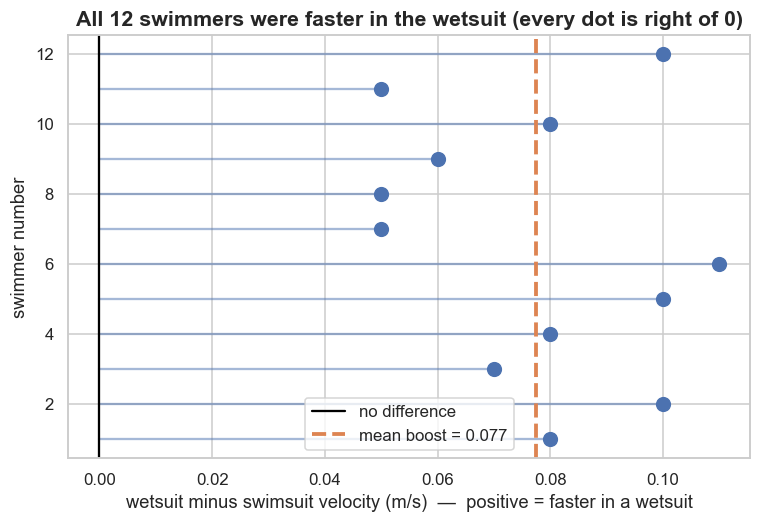

Every dot sits to the RIGHT of the black zero line. The effect is small but strikingly
one-directional. The job of the next two sections is to say how SURE we can be of it.


In [3]:
fig, ax = plt.subplots()
ax.scatter(d, np.arange(1, n + 1), s=80, color='#4c72b0', zorder=5)
for i, di in enumerate(d, start=1):
    ax.plot([0, di], [i, i], color='#4c72b0', lw=1.5, alpha=0.5)   # stem from 0 to each diff
ax.axvline(0, color='black', lw=1.5, label='no difference')
ax.axvline(d.mean(), color='#dd8452', lw=2.5, ls='--', label=f'mean boost = {d.mean():.3f}')
ax.set_xlabel('wetsuit minus swimsuit velocity (m/s)  —  positive = faster in a wetsuit')
ax.set_ylabel('swimmer number')
ax.set_title('All 12 swimmers were faster in the wetsuit (every dot is right of 0)')
ax.legend(); plt.show()
print('Every dot sits to the RIGHT of the black zero line. The effect is small but strikingly')
print('one-directional. The job of the next two sections is to say how SURE we can be of it.')

## 2) A bootstrap confidence interval for the mean boost

We want a 95% confidence interval for the **true mean wetsuit boost** — how much faster the wetsuit
makes swimmers *on average*. In the core lesson the recipe was identical, so we reuse the very same
helper:

> **Resample the data WITH replacement**, the same size as the original. Recompute the statistic.
> Repeat thousands of times. The middle 95% of those values (the **2.5th to 97.5th percentiles**) is
> the confidence interval.

The only twist here is the tiny sample. Our "data" is just the **12 differences**, so each bootstrap
resample draws 12 differences *with replacement* from those 12 — some swimmers appear twice or three
times, others not at all — and we take the mean. With only 12 values to draw from, the bootstrap can
land on relatively few distinct means, which is the honest fingerprint of a small sample (you will see
the histogram look a little chunky). That is a feature, not a bug: the bootstrap never pretends to know
more than the 12 numbers it was given.

In [4]:
def bootstrap_statistic(data, stat_fn, n_boot=10000, seed=SEED):
    '''Resample `data` WITH replacement n_boot times; return stat_fn of each resample.'''
    rng = np.random.default_rng(seed)
    data = np.asarray(data)
    m = len(data)
    out = np.empty(n_boot)
    for i in range(n_boot):
        resample = rng.choice(data, size=m, replace=True)   # 12 values, WITH replacement
        out[i] = stat_fn(resample)
    return out

boot_means = bootstrap_statistic(d, np.mean, n_boot=10000)

lo, hi = np.percentile(boot_means, [2.5, 97.5])             # the percentile method
print(f'Observed mean boost        = {d.mean():.4f} m/s')
print(f'95% bootstrap CI (mean)    = ({lo:.4f}, {hi:.4f}) m/s')
print(f'Bootstrap SE of the mean   = {boot_means.std(ddof=1):.4f} m/s')
print(f'\nThe whole interval sits ABOVE 0 -> 0 (no effect) is not a plausible value for the boost.')

Observed mean boost        = 0.0775 m/s
95% bootstrap CI (mean)    = (0.0658, 0.0892) m/s
Bootstrap SE of the mean   = 0.0060 m/s

The whole interval sits ABOVE 0 -> 0 (no effect) is not a plausible value for the boost.


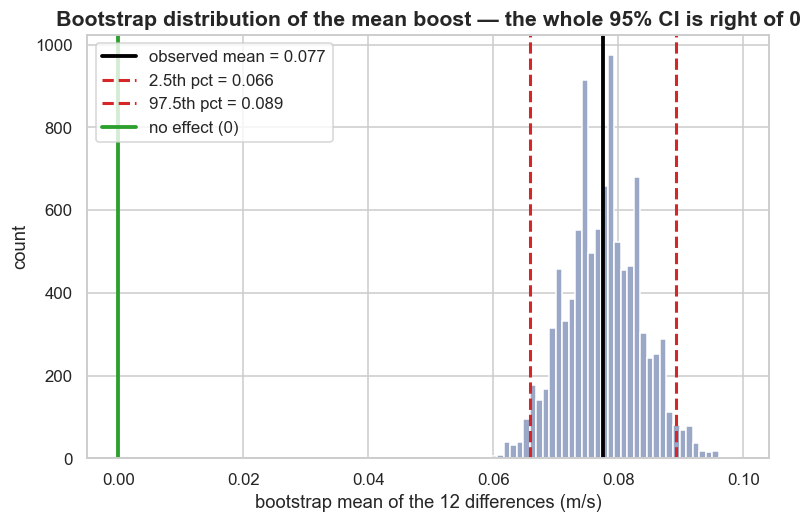

The green "no effect" line sits far to the LEFT of the entire bootstrap distribution.
A wetsuit boost of exactly zero is simply not where resampling ever lands.


In [5]:
fig, ax = plt.subplots()
ax.hist(boot_means, bins=40, color='#9aa7c7', edgecolor='white')
ax.axvline(d.mean(), color='black', lw=2.5, label=f'observed mean = {d.mean():.3f}')
ax.axvline(lo, color='#d62728', lw=2, ls='--', label=f'2.5th pct = {lo:.3f}')
ax.axvline(hi, color='#d62728', lw=2, ls='--', label=f'97.5th pct = {hi:.3f}')
ax.axvline(0, color='#2ca02c', lw=2.5, label='no effect (0)')
ax.set_xlabel('bootstrap mean of the 12 differences (m/s)'); ax.set_ylabel('count')
ax.set_title('Bootstrap distribution of the mean boost — the whole 95% CI is right of 0')
ax.legend(); plt.show()
print('The green "no effect" line sits far to the LEFT of the entire bootstrap distribution.')
print('A wetsuit boost of exactly zero is simply not where resampling ever lands.')

**Reading the interval (the three levels):**

- **The math:** resample the 12 differences with replacement $B = 10{,}000$ times, take the mean each
  time, and slice off the 2.5th and 97.5th percentiles of those means.
- **The meaning:** the bootstrap distribution imitates the sampling distribution of the mean, so its
  middle 95% is a range of plausible values for the *true* mean boost — built by simulation, with **no
  formula and no assumption that the 12 differences are normal.**
- **The real-world reading:** we are 95% confident the wetsuit makes swimmers faster by roughly the
  range between the dashed red lines — a small but unmistakably **positive** edge, since the whole
  interval lies above zero.

## 3) Sanity check: does the bootstrap agree with the textbook t-interval?

A new method earns trust by **matching the old one where the old one applies.** The classical tool for
the mean of paired differences is the **one-sample $t$ interval** on the 12 $d_i$ values:
$\bar d \pm t^{*}\, s/\sqrt{n}$. That formula *does* assume the differences are roughly normal — a leap
of faith with only 12 of them — but if the bootstrap (which assumes nothing of the sort) lands in the
same place, that is reassuring for both methods.

In [6]:
xbar = d.mean()
s    = d.std(ddof=1)
se   = s / np.sqrt(n)
tcrit = stats.t.ppf(0.975, df=n - 1)
t_lo, t_hi = xbar - tcrit * se, xbar + tcrit * se

print(f'Bootstrap 95% CI (mean): ({lo:.4f}, {hi:.4f}) m/s   (no normality assumed)')
print(f't-interval  95% CI (mean): ({t_lo:.4f}, {t_hi:.4f}) m/s   (assumes ~normal differences)')
print()
print(f'Bootstrap SE of mean      = {boot_means.std(ddof=1):.4f} m/s')
print(f'Formula  SE = s/sqrt(n)   = {se:.4f} m/s   <- the bootstrap rediscovered the formula')
print('\nThe two intervals nearly coincide -> the bootstrap is trustworthy here, and it')
print('reached that interval WITHOUT betting on normality, which matters most when n is tiny.')

Bootstrap 95% CI (mean): (0.0658, 0.0892) m/s   (no normality assumed)
t-interval  95% CI (mean): (0.0637, 0.0913) m/s   (assumes ~normal differences)

Bootstrap SE of mean      = 0.0060 m/s
Formula  SE = s/sqrt(n)   = 0.0063 m/s   <- the bootstrap rediscovered the formula

The two intervals nearly coincide -> the bootstrap is trustworthy here, and it
reached that interval WITHOUT betting on normality, which matters most when n is tiny.


## 4) A permutation test: could the boost be pure luck?

The interval already tells us a lot, but let's pose the question as a formal hypothesis test, the way
the core lesson did. Here the natural null hypothesis is:

> **$H_0$: the wetsuit makes no difference at all.**

Think about what that null *means for a paired design*. If the wetsuit truly did nothing, then for each
swimmer the label "wetsuit" versus "swimsuit" on their two swims is arbitrary — any difference we see is
just random noise that could just as easily have come out the other way. In other words, **under the
null the sign of each swimmer's difference $d_i$ is equally likely to be $+$ or $-$.**

That gives us a clean way to build the null distribution by hand — the **sign-flip permutation test**:

> **Randomly flip the $+/-$ sign of each of the 12 differences** (a coin flip per swimmer), recompute
> the mean, and repeat thousands of times. Because the signs are now random, this manufactures the
> distribution of the mean **when the wetsuit does nothing**. The **p-value** is the fraction of those
> null means that are as extreme as our observed mean, in *either* direction.

This is the paired cousin of the label-shuffling in the core lesson: there we shuffled *group labels*
between two piles; here, because the data is paired, we shuffle the *sign* within each pair.

In [7]:
def sign_flip_test(diffs, n_perm=20000, seed=SEED):
    '''Build the null by randomly flipping each difference's sign; return (observed, null_means).'''
    rng = np.random.default_rng(seed)
    diffs = np.asarray(diffs)
    m = len(diffs)
    observed = diffs.mean()
    signs = rng.choice([-1, 1], size=(n_perm, m))     # a +/- coin flip per swimmer, each permutation
    null_means = (signs * diffs).mean(axis=1)         # mean of the sign-flipped differences
    return observed, null_means

observed_mean, null_means = sign_flip_test(d, n_perm=20000)

# Two-sided p-value: fraction of sign-flip means at least as extreme as observed (either direction).
p_perm = np.mean(np.abs(null_means) >= np.abs(observed_mean))
print(f'Observed mean boost            = {observed_mean:.4f} m/s')
print(f'Sign-flip permutation p-value  = {p_perm:.5f}')
print(f'Spread of the null means       = {null_means.std():.4f} m/s   (the "by-chance" wobble)')
print(f'\nOnly {int(round(p_perm * len(null_means)))} of {len(null_means):,} random sign-flips reached our observed boost.')

Observed mean boost            = 0.0775 m/s
Sign-flip permutation p-value  = 0.00060
Spread of the null means       = 0.0229 m/s   (the "by-chance" wobble)

Only 12 of 20,000 random sign-flips reached our observed boost.


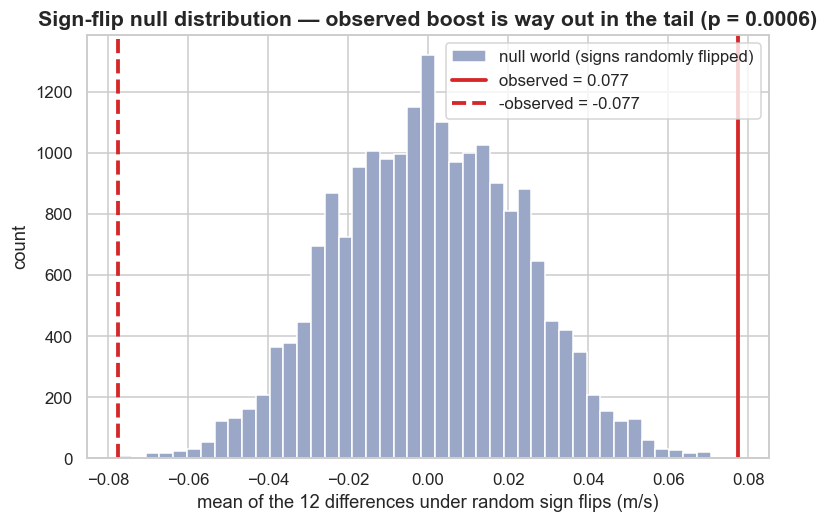

The grey histogram is "what the mean looks like if the wetsuit does nothing." Our observed
boost (red line) sits far beyond almost every sign-flip, so chance alone is a poor explanation.


In [8]:
fig, ax = plt.subplots()
ax.hist(null_means, bins=45, color='#9aa7c7', edgecolor='white',
        label='null world (signs randomly flipped)')
ax.axvline(observed_mean, color='#d62728', lw=2.5, label=f'observed = {observed_mean:.3f}')
ax.axvline(-observed_mean, color='#d62728', lw=2.5, ls='--', label=f'-observed = {-observed_mean:.3f}')
ax.set_xlabel('mean of the 12 differences under random sign flips (m/s)'); ax.set_ylabel('count')
ax.set_title(f'Sign-flip null distribution — observed boost is way out in the tail (p = {p_perm:.4f})')
ax.legend(); plt.show()
print('The grey histogram is "what the mean looks like if the wetsuit does nothing." Our observed')
print('boost (red line) sits far beyond almost every sign-flip, so chance alone is a poor explanation.')

## 5) Cross-check, and the big picture

The classical partner of the sign-flip test is the **paired (one-sample) $t$-test** on the 12
differences — the t-tests lesson covers it in full. If the permutation p-value lands near `scipy`'s, we
get the same verdict with **fewer assumptions** (the sign-flip test never assumed the differences were
normal).

In [9]:
t_result = stats.ttest_1samp(d, popmean=0)     # paired test = one-sample t on the differences vs 0
print(f'Sign-flip permutation p-value = {p_perm:.5f}   (no distribution assumed)')
print(f'Paired (one-sample) t-test p  = {t_result.pvalue:.2e}   (assumes ~normal differences)')
print()
verdict = 'reject' if p_perm < 0.05 else 'do NOT reject'
print(f'Both p-values are tiny (far below 0.05), so we {verdict} H0:')
print('the wetsuit speed boost is REAL, not a fluke of which 12 swimmers we tested.')
print('The two methods AGREE -- and the permutation test earned that answer without assuming normality.')

Sign-flip permutation p-value = 0.00060   (no distribution assumed)
Paired (one-sample) t-test p  = 8.89e-08   (assumes ~normal differences)

Both p-values are tiny (far below 0.05), so we reject H0:
the wetsuit speed boost is REAL, not a fluke of which 12 swimmers we tested.
The two methods AGREE -- and the permutation test earned that answer without assuming normality.


Both p-values are minuscule, so the conclusion is not in doubt: **the wetsuit really does make swimmers
faster.** What is striking is that we reached a rock-solid verdict from **only 12 numbers** — precisely
the regime where you should be most suspicious of a formula's fine print, and where resampling shines.

> **What changed from the core lesson — and what didn't:**
>
> | | **Core (Lesson 20)** | **This lesson** |
> |---|---|---|
> | **Sample size** | $n = 272$ eruptions, 60 guinea pigs | $n = 12$ paired swimmers |
> | **Design** | two *separate* groups (OJ vs VC) | *paired* — each swimmer is their own control |
> | **Bootstrap** | CI for a **median** (no SE formula) | CI for the **mean boost** (tiny sample) |
> | **Permutation move** | **shuffle group labels** between two piles | **flip the $\pm$ sign** within each pair |
> | **Why resampling wins** | the statistic has no clean formula | the **sample is tiny** — formulas are least trustworthy |
>
> The machinery is the same; only the reason it's the right tool changes. With $n = 12$, a formula asks
> you to *bet* that the data is normal; the bootstrap and the sign-flip test ask you to bet nothing.

Notice the two tools answered two different questions, exactly as in the core lesson. The **bootstrap**
gave us a *confidence interval* — "how big is the boost, and how precisely do we know it?" The
**permutation test** gave us a *p-value* — "could the boost be zero?" Together they tell the full story:
the wetsuit advantage is **real** (tiny p-value) and we can put numbers on **how large** it is (the
interval), all from twelve swimmers and not one normality assumption.

## Now you try

Predict first, then change a number and re-run:

1. **A different statistic, same machine.** The `bootstrap_statistic` helper takes *any* function. In a
   new cell, bootstrap the **median** boost instead of the mean:

       boot_med = bootstrap_statistic(d, np.median, n_boot=10000)
       print(np.percentile(boot_med, [2.5, 97.5]))

   With only 12 values, watch how *chunky* (discrete) the median's bootstrap distribution is.

2. **Change the seed.** `SEED` at the top drives both the bootstrap and the sign-flip test. Try a few
   values (e.g. `SEED = 0`, `7`, `123`). The CI endpoints and the p-value wiggle a *little* each time —
   that wiggle is Monte-Carlo noise, the price of simulation; bigger `n_boot` / `n_perm` shrinks it.

3. **How extreme is the maximum possible evidence?** There are only $2^{12} = 4096$ possible sign
   patterns. The most extreme is "all 12 differences positive" — which is *exactly what we observed*.
   In a new cell, compute the smallest p-value the sign-flip test could ever give here:

       print(2 / 2**12)   # two-sided: the all-+ and all-- patterns

   How close is our simulated p-value to this floor? What does that tell you about the evidence?

4. **Break the pairing on purpose.** Pretend we *forgot* this was paired and instead compared the 12
   wetsuit swims against the 12 swimsuit swims as two separate groups with the core lesson's label
   shuffle. The swimmer-to-swimmer spread is huge, so the effect gets buried. Try it and see how much
   weaker the signal looks — that is the payoff of pairing.

## What you learned

- **Pairing isolates the effect:** because each swimmer swam both ways, we work with **one difference
  per swimmer**, cancelling out how fast each person simply *is* — leaving a clean view of the wetsuit's
  effect from just 12 numbers.
- **The bootstrap still works on a tiny sample:** resample the 12 differences *with replacement*, take
  the mean each time, and the 2.5th–97.5th percentiles give a 95% CI for the boost — entirely above
  zero, with **no normality assumption**.
- **It agreed with the textbook t-interval**, so we trust it — and unlike the formula, it never had to
  bet that 12 differences are normal.
- **The sign-flip permutation test** builds the null by hand: under "the wetsuit does nothing," each
  difference's $\pm$ sign is a coin flip, so we flip signs thousands of times and read the p-value off
  the tail. It came out tiny — the boost is real.
- **It agreed with the paired t-test** while assuming **less** — the paired cousin of the core lesson's
  label shuffle.
- **Same two tools, a new reason to use them:** the core lesson reached for resampling because a
  *statistic* (the median) had no formula; here we reach for it because the *sample* is tiny — the place
  textbook formulas are least trustworthy and resampling earns its keep.

---

**↩ Back to the lesson:** [Lesson 20: The bootstrap & permutation tests](20-bootstrap-permutation.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  **Also:** [The code behind it](20-bootstrap-permutation~the-code.ipynb)